In [1]:
#!/usr/bin/env python
# coding: utf-8


import os
#Directory here
os.chdir('/Users/cherryleheu/Codes/NIDIS-Codes/H-RIP/Python')


import geopandas as gpd
import shapely 
from shapely.geometry import Point
import matplotlib.pyplot as plt
# from dms2dec.dms_convert import dms2dec
import numpy as np
import pandas as pd
import rasterio
from rasterio.plot import show
from rasterstats import zonal_stats
from datetime import datetime, timedelta
import calendar
from dateutil.relativedelta import *
from standard_precip import spi

In [2]:
# Read the shapefile
gdf = gpd.read_file('./shapefiles/RID.shp')
gdf

,id,FID,Polygon,Area,IS,musym,geometry
0,None,0,RID001,001,BI,421,"POLYGON ((-155.76628 20.14654, -155.76628 20.1..."
1,None,0,RID002,002,BI,417,"POLYGON ((-155.80599 20.14695, -155.80599 20.1..."
2,None,0,RID003,003,BI,370,"POLYGON ((-155.83945 20.12219, -155.83945 20.1..."
3,None,0,RID004,004,OA,WaB,"POLYGON ((-158.06116 21.62715, -158.06116 21.6..."
4,None,0,RID005,005,OA,KpF,"POLYGON ((-158.09522 21.54064, -158.09522 21.5..."
...,...,...,...,...,...,...,...
110,None,0,RID111,NaN,BI,952,"POLYGON ((-155.2068 19.96392, -155.2068 19.943..."
111,None,0,RID112,NaN,MA,ISD,"POLYGON ((-156.38562 20.64516, -156.38562 20.6..."
112,None,0,RID113,NaN,MO,HvB3,"POLYGON ((-157.02678 21.13557, -157.02678 21.1..."
113,None,0,RID114,NaN,MO,HvB3,"POLYGON ((-157.02678 21.13557, -157.02678 21.1..."


In [3]:
'''
Log
RID077 -155.562160606208 19.8879886274348
RID078 -155.602329368419 19.873136978495
RID079 -155.570057029552 19.9767465825001
RID080 -155.6598359297 20.0048159791584
RID081 -155.670478935067 20.0481201384305
RID082 -155.73429405195 20.0863138483643
RID083 -155.751834149437 20.1375566978253
RID084 -155.83383619291 20.1670643761859
RID085 -155.684900164623 18.9424641452124
RID086 -155.667619060971	19.0055991086339
RID087 -155.485133587008	19.1629174428649
RID088 -155.679116602317	18.9347910168347
RID089 -155.915857220744	19.5064142062338
RID090 -155.933211721583	19.5235631522107
RID091 -155.946759847527	19.5190590350399
RID092 -155.590774773589	19.9923654020665
RID093 -155.564339485203	20.0390970223757
RID094 -155.390944      19.968048
RID095 -155.351864      20.029628
RID096 -155.258204      19.999723
RID097 -156.359329      20.794674
RID098 -156.653649      20.881851
RID099 -155.653645      19.864262
RID100 -155.139514      19.524121
RID101 -155.486335      20.049087
RID102 -155.829929      20.206586
RID103 -155.02305       19.513853
RID104 -155.792366      19.406898
RID105 -155.789963      19.396834
RID106 -157.750789      21.372408 Oa
RID107 -155.067474      19.589526 
RID108 -155.486091      20.04892  
RID109 -155.907685      19.645501 
RID110 -158.173473      21.50691 Oa
RID111 -155.216799      19.953918 
RID112 -156.39562       20.635159 MA
RID113 -157.036775      21.125567 MO
RID115 -155.129532      19.901619 BI
RID116 -155.477703      19.53052 BI
'''

#if coordinates are in convert degree minute second format, convert to decimals below
#lat=dms2dec('''19°45ʻ17.00"N''') # converts to dec
#lon=dms2dec('''155°52ʻ12.32"W''') # converts to dec

lat = 19.53052
lon = -155.477703 

#Get the number of ranches in HRIP
dir_path = '../RID'
count = 0
for path in os.listdir(dir_path):
    if os.path.isdir(os.path.join(dir_path, path)):
        count += 1
r = count+1
ranch_id='RID'+f"{count+1:03}"
ranch_name = ''

#Island names: BI, MA, OA, KA, LA, KO, MO
island='BI'


p1 = Point(lon,lat)
points = gpd.GeoSeries([p1])

# Buffer the points using a square cap style
# Note cap_style: round = 1, flat = 2, square = 3
buffer = points.buffer(0.01, cap_style = 3)



buffer.to_file('./shapefiles/RIDs/'+ranch_id+'.shp')  



#Enter new location into shapefile compilations

ranchshp = gpd.read_file('./shapefiles/RID.shp')



newshp = gpd.read_file('./shapefiles/RIDs/'+ranch_id+'.shp')
newshp['Polygon']= ranch_id
#Name of area (optional)
newshp['Area']= ranch_name
#Island
newshp['IS']= island
new = pd.concat([ranchshp, newshp])
#new=ranchshp.append(newshp, ignore_index=True)
new.to_file('./shapefiles/RID.shp')  
os.mkdir('../RID/'+ranch_id)



a = "var ranchSquares = "+new.to_json()
file_path = "../Leaflet/ranches.js"

with open(file_path, "w") as js_file:
    js_file.write(a)
    
months = np.arange(1,13,1)
legacyYears = np.arange(1920,1990)
newYears=np.arange(1990,2020)

thisYear=(datetime.today().strftime("%Y"))
thisMonth=int((datetime.today().strftime("%m")))
yestYr, yestMonth, yestDay = int((datetime.today() + relativedelta(days=-1)).strftime("%Y")),int((datetime.today() + relativedelta(days=-1)).strftime("%m")),int((datetime.today() + relativedelta(days=-1)).strftime("%d"))

lastMonth = int((datetime.today() + relativedelta(months=-1)).strftime("%m"))
lastMonthYr = (datetime.today() + relativedelta(months=-1)).strftime("%Y")
lastMonthDays = calendar.monthrange(int(lastMonthYr), int(lastMonth))[1]

recentYears=np.arange(2020,int(lastMonthYr)+1)
year=int(thisYear)

'''if int(datetime.today().strftime("%m"))==1:
    lastMonth=12
    recentYears=np.arange(2020,int(thisYear))
    year=int(thisYear)-1
else:
    thisMonth=int((datetime.today().strftime("%m")))
    recentYears=np.arange(2020,int(thisYear)+1)
    year=int(thisYear)'''


today = datetime.today()

last_month = today.replace(day=1) - timedelta(days=1)
first_day_of_last_month = last_month.replace(day=1)

lastM = first_day_of_last_month.strftime('%m/%d/%y')

/opt/anaconda3/envs/hrip/lib/python3.14/site-packages/pyogrio/geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
/opt/anaconda3/envs/hrip/lib/python3.14/site-packages/geopandas/array.py:1754: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as WGS 84 (the single non-null crs provided).
  return GeometryArray(data, crs=_get_common_crs(to_concat))


In [4]:
#Legacy
rf= pd.DataFrame({'Year': [],'Month':[],'RF_mm': []})
for i in legacyYears:
    for j in months:
        ranchshp = gpd.read_file(f'./shapefiles/RIDs/RID{r:03d}.shp')

        with rasterio.open(f"./rain_monthly_maps/legacy/rainfall_{i}_{j:02d}.tif") as src:
            affine = src.transform
            array = src.read(1)
            df_zonal_stats = pd.DataFrame(zonal_stats(ranchshp, array, affine=affine,nodata=src.nodata,stats = ['mean']))
        RF= df_zonal_stats['mean'].iloc[0]
        new_row = pd.DataFrame({'Year':i,'Month':j,'RF_mm':RF},index=[0])
        rf=pd.concat([rf, new_row],ignore_index=True)
        #rf=rf.append({'Year':i,'Month':j,'RF_mm':RF},ignore_index=True)
        rf['RF_in']=rf['RF_mm']/25.4
        rf.to_csv(f'./ranch_rf/legacy/RID{r:03d}_rf.csv',index=False)
#New

csv = pd.read_csv(f'./ranch_rf/legacy/RID{r:03d}_rf.csv')
for i in newYears:
    for j in months:
        with rasterio.open(f"./rain_monthly_maps/1990-2019/rainfall_{i}_{j:02d}.tif") as src:
            affine = src.transform
            array = src.read(1)
            df_zonal_stats = pd.DataFrame(zonal_stats(ranchshp, array, affine=affine,nodata=src.nodata,stats = ['mean']))
        RF= df_zonal_stats['mean'].iloc[0]
        print(RF)
        new_row = pd.DataFrame({'Year':i,'Month':j,'RF_mm':RF,'RF_in':RF/25.4},index=[0])
        csv=pd.concat([csv, new_row],ignore_index=True)
        #csv = csv.append({},ignore_index=True)
        csv.to_csv(f'./ranch_rf/1990-2019/RID{r:03d}_rf.csv',index=False)

#2020-now

csv = pd.read_csv(f'./ranch_rf/1990-2019/RID{r:03d}_rf.csv')
for i in recentYears:
    for j in months:
        if int(i) == int(thisYear) and int(j)==(thisMonth):
            break
        with rasterio.open(f"./rain_monthly_maps/2020-/rainfall_{i}_{j:02}.tif") as src:
            affine = src.transform
            array = src.read(1)
            df_zonal_stats = pd.DataFrame(zonal_stats(ranchshp, array, affine=affine,nodata=src.nodata,stats = ['mean']))
        RF= df_zonal_stats['mean'].iloc[0]
        new_row = pd.DataFrame({'Year':i,'Month':j,'RF_mm':RF,'RF_in':RF/25.4},index=[0])
        csv=pd.concat([csv, new_row],ignore_index=True)
        #csv=csv.append({},ignore_index=True)
csv['datetime']=pd.date_range('1/1/1920',lastM,freq='MS')
csv.to_csv(f'../RID/RID{r:03d}/RID{r:03d}_rf.csv',index=False)

spi_rain = spi.SPI()
spi_3=[]
spi_3 = spi_rain.calculate(csv, 'datetime', 'RF_in', freq="M", scale=3, fit_type="lmom", dist_type="gam")
spi_3=spi_3.rename(columns={"RF_in_scale_3_calculated_index": "SPI-3"})
spi_3.to_csv(f'../RID/RID{r:03d}/RID{r:03d}_spi.csv')

datem = datetime.today().strftime("%m")
monthInd = -int(datem)+1

#average monthly
def rf_avg(arr):
    arr = arr.drop(['datetime'], axis=1)
    rfdf = arr.groupby(['Month'],as_index=False).mean()
    rfdf['Month'] = rfdf['Month'].astype(np.uint8).apply(lambda x: calendar.month_name[x])
    rfdf['rolledMonth'] = np.roll(rfdf.Month, monthInd)
    rfdf['RF'] = np.roll(rfdf.RF_in, monthInd)
    rfdf = rfdf.rename(columns={"Month":"oldMonth","rolledMonth":"Month"})
    return rfdf

#last 12 months
def rf_12m(arr):
    rf12m = arr.copy()
    rf12m['Month'] = rf12m['Month'].astype(np.uint8).apply(lambda x: calendar.month_name[x])
    rf12m = rf12m.tail(12)
    rf12m['RF'] = rf12m['RF_in'] 
    return rf12m

rf = pd.read_csv(f"../RID/RID{r:03d}/RID{r:03d}_rf.csv")    
rfdf=rf_avg(rf)
rfdf=rfdf.drop(['Year','RF_mm'],axis=1)
rf12m=rf_12m(rf)
rf12m=rf12m.drop(['Year','datetime','RF_mm','RF_in'],axis=1)
rfdf.to_csv(f'../RID/RID{r:03d}/RID{r:03d}_rf_month.csv', index=False) 
rf12m.to_csv(f'../RID/RID{r:03d}/RID{r:03d}_rf_12m.csv')

172.77364245756172
117.04282407407408
54.99913194444444
7.488740897472994
13.222532672646604
18.266078619309415
34.9850169994213
23.307484567901234
53.00641396604938
57.10230999228395
185.92643229166666
96.03444492669753
15.055558569637345
19.752445927372687
122.68414834104938
21.858473789544753
39.37149763695987
20.91119158709491
32.89064609857253
70.16174768518519
32.383885513117285
8.515386134018133
9.594630111882717
25.486201533564813
20.065999348958332
5.21332389925733
22.371211299189813
9.859649281442902
11.738315911940587
7.245629581404321
78.61486665702161
50.228609061535494
96.61216001157408
22.95226447964892
89.21750819830247
71.9958827642747
36.06288278838735
8.356247136622299
16.800345715181326
12.559578601224922
16.447212878568674
9.629129292052468
96.2695011091821
29.75997359664352
31.919861593364196
54.571090133101855
38.84807822145062
34.66312512056327
61.473885995370374
121.57468894675925
83.7355022665895
12.646683304398149
13.188301745756172
30.84499782986111
49.35182

In [18]:
# # Read the shapefile
# gdf = gpd.read_file('./shapefiles/RID.shp')
# #print(gdf)

# # Drop rows 100 to 108 (inclusive)
# gdf = gdf.drop(gdf.index[101])

# # Optionally, reset the index if you want a continuous index
# gdf = gdf.reset_index(drop=True)

# # Save the modified GeoDataFrame if needed
# gdf.to_file('./shapefiles/RID.shp')

In [5]:
#Daily rainfall
lastMonthDailyRF = []
thisMonthDailyRF = []
pd.options.display.float_format = '{:.6f}'.format

# 1. Read the shapefile ONCE outside the loop for much better performance
ranchshp = gpd.read_file('./shapefiles/RID.shp', rows=slice(r-1, r))

# 2. Extract the geometries to ensure rasterstats recognizes it
vectors = ranchshp.geometry 

for day in np.arange(1, lastMonthDays+1):
    with rasterio.open(f'./rain_daily_maps/{thisYear}_{lastMonth:02d}_{day:02d}.tif') as src:
        affine = src.transform
        array = src.read(1)
        
        # 3. Pass the extracted vectors instead of the whole GeoDataFrame
        stats = zonal_stats(vectors, array, affine=affine, nodata=src.nodata, stats=['mean'])
        df_zonal_stats = pd.DataFrame(stats)
        
    rf = (df_zonal_stats['mean'].iloc[0]) / 25.4
    row = {'Year': lastMonthYr, 'Month': lastMonth, 'Day': day, 'RF_in': rf}
    lastMonthDailyRF.append(row)

df = pd.DataFrame(lastMonthDailyRF)
df.to_csv(f'../RID/RID{r:03d}/RID{r:03d}_rf_daily_last_month.csv', index=False)

for day in np.arange(1,yestDay+1):
    ranchshp = gpd.read_file('./shapefiles/RID.shp',rows=slice(r-1, r))
    with rasterio.open(f'./rain_daily_maps/{yestYr}_{yestMonth:02d}_{day:02d}.tif') as src:
        affine = src.transform
        array = src.read(1)
        df_zonal_stats = pd.DataFrame(zonal_stats(ranchshp, array, affine=affine,nodata=src.nodata,stats = ['mean']))
    rf = (df_zonal_stats['mean'].iloc[0])/25.4
    row = {'Year': yestYr, 'Month': yestMonth, 'Day':day, 'RF_in': rf}
    thisMonthDailyRF.append(row)
df = pd.DataFrame(thisMonthDailyRF)
df.to_csv(f'../RID/RID{r:03d}/RID{r:03d}_rf_daily_this_month.csv',index=False)

#yesterday's rf
rfdf = pd.read_csv(f'../RID/RID{r:03d}/RID{r:03d}_rf_daily_this_month.csv')
rf = rfdf['RF_in'].iloc[-1]
yest_year = rfdf['Year'].iloc[-1]
yest_mon = rfdf['Month'].iloc[-1]
yest_day = rfdf['Day'].iloc[-1]
with open(f'../RID/RID{r:03d}/RID{r:03d}_rf_d.txt', 'w') as f:
    f.write(str(rf)+f'\n{yest_year}\n{yest_mon}\n{yest_day}') 

In [25]:
consec_dry = 0
rfdf = pd.read_csv(f'../RID/RID{r:03d}/RID{r:03d}_rf_daily_this_month.csv')
for index in reversed(np.arange(len(rfdf))):
    rf = rfdf['RF_in'].iloc[index]
    if rf<0.0393701:
        consec_dry+=1
    else:
        break
if consec_dry == len(rfdf):
    lastMrfdf = pd.read_csv(f'../RID/RID{r:03d}/RID{r:03d}_rf_daily_last_month.csv')
    for index in reversed(np.arange(len(lastMrfdf))):
        rf = lastMrfdf['RF_in'].iloc[index]
        if rf<0.0393701:
            consec_dry+=1
        else:
            break
with open(f'../RID/RID{r:03d}/RID{r:03d}_consec_dry_days.txt', 'w') as f:
    f.write(str(consec_dry))

In [9]:
temp = pd.DataFrame({'Year': [],'Month':[],'tmean_f': []})
for i in np.arange(1990,int(thisYear)+1):
    for j in months:
        if int(i) == int(thisYear) and int(j)==(thisMonth):
            break
        with rasterio.open(f'/Users/cherryleheu/Documents/HCDP/Data/monthly/tmean/tmean_{i}_{j:02d}.tif') as src:
            affine = src.transform
            array = src.read(1)
            df_zonal_stats = pd.DataFrame(zonal_stats(ranchshp, array, affine=affine,nodata=-9999,stats = ['mean']))
        temp_f = 9/5*df_zonal_stats['mean'].iloc[0]+32
        new_row = pd.DataFrame({'Year':i,'Month':j,'tmean_f':temp_f},index=[0])
        temp=pd.concat([temp, new_row],ignore_index=True)
temp['datetime']=pd.date_range('1/1/1990',lastM,freq='MS')
temp.to_csv(f'../RID/RID{r:03d}/RID{r:03d}_tmean.csv',index=False)

#Min/Max temp

last_year, last_mon = int((datetime.today() + relativedelta(months=-1)).strftime("%Y")),int((datetime.today() + relativedelta(months=-1)).strftime("%m"))
a = ['mean','max','min']
temp_m = {}

for n in a:
    ranchshp = gpd.read_file('./shapefiles/RID.shp',rows=slice(r-1, r))
    with rasterio.open(f'./temp_monthly_maps/{n}/t_month_{n}_{last_year}_{last_mon:02d}.tif') as src:
        affine = src.transform
        array = src.read(1)
        df_zonal_stats = pd.DataFrame(zonal_stats(ranchshp, array, affine=affine,nodata=-9999,stats = ['mean']))
    temp_m[n]=9/5*df_zonal_stats['mean'].iloc[0]+32 
mean_v = float(temp_m["mean"])
max_v  = float(temp_m["max"])
min_v  = float(temp_m["min"])
with open(f'../RID/RID{r:03d}/RID{r:03d}_temp_m.txt', 'w') as f:
    f.write(
        f"{mean_v}\n{max_v}\n{min_v}\n{last_year}\n{last_mon}"
    )

def temp_avg(arr):
    tdf = arr.groupby(['Month'],as_index=False)['tmean_f'].mean()
    tdf['Month'] = tdf['Month'].astype(np.uint8).apply(lambda x: calendar.month_name[x])
    tdf['rolledMonth'] = np.roll(tdf.Month, monthInd) 
    tdf['NewTemp'] = np.roll(tdf.tmean_f, monthInd)
    tdf = tdf.rename(columns={"Month":"oldMonth","Temp":"OldTemp","NewTemp": "Temp","rolledMonth":"Month"})
    return tdf

def temp_12m(arr):
    tdf12m = arr
    tdf12m['Month'] = tdf12m.tail(12)['Month'].astype(np.uint8).apply(lambda x: calendar.month_name[x])
    tdf12m = arr.tail(12)
    return tdf12m

temp = pd.read_csv(f"../RID/RID{r:03d}/RID{r:03d}_tmean.csv")    
tdf=temp_avg(temp)
tdf12m=temp_12m(temp)
tdf12m=tdf12m.drop(['Year','datetime'],axis=1)
tdf.to_csv(f'../RID/RID{r:03d}/RID{r:03d}_t_month.csv') 
tdf12m.to_csv(f'../RID/RID{r:03d}/RID{r:03d}_t_12m.csv')

#Daily Temp
yest_year, yest_mon, yest_day = int((datetime.today() + relativedelta(days=-1)).strftime("%Y")),int((datetime.today() + relativedelta(days=-1)).strftime("%m")),int((datetime.today() + relativedelta(days=-1)).strftime("%d"))
a = ['mean','max','min']
temp = {}

for n in a:
    ranchshp = gpd.read_file('./shapefiles/RID.shp',rows=slice(r-1, r))
    with rasterio.open(f'./temp_daily_maps/{n}/{yest_year}_{yest_mon:02d}_{yest_day:02d}_{n}.tif') as src:
        affine = src.transform
        array = src.read(1)
        df_zonal_stats = pd.DataFrame(zonal_stats(ranchshp, array, affine=affine,nodata=-9999,stats = ['mean']))
    temp[n]=9/5*df_zonal_stats['mean'].iloc[0]+32 
mean_v = float(temp["mean"])
max_v  = float(temp["max"])
min_v  = float(temp["min"])
with open(f'../RID/RID{r:03d}/RID{r:03d}_temp_d.txt', 'w') as f:
    f.write(
        f"{mean_v}\n{max_v}\n{min_v}\n{yest_year}\n{yest_mon}\n{yest_day}"
    )




In [10]:
ndvi = pd.DataFrame({'Year': [],'Month':[],'NDVI': []})
for i in np.arange(2000,int(thisYear)+1):
    for j in months:
        if (i == 2000 and j < 4):
                continue  
        if int(i) == int(thisYear) and int(j)==(thisMonth):
            break
        with rasterio.open(f"./NDVI_maps/NDVI_{i}_{j:02d}.tif") as src:
            affine = src.transform
            array = src.read(1)
            nodata=src.nodata
        stats = zonal_stats(ranchshp, array, affine=affine,nodata=nodata,stats = ['mean'])
        mean_ndvi = stats[0]['mean']
        new_row = pd.DataFrame({'Year':i,'Month':j,'NDVI':mean_ndvi},index=[0])
        ndvi=pd.concat([ndvi, new_row],ignore_index=True)
ndvi['datetime']=pd.date_range('4/1/2000',lastM,freq='MS')
ndvi.to_csv(f'../RID/RID{r:03d}/RID{r:03d}_ndvi.csv',index=False)

datem = datetime.today().strftime("%m")
monthInd = -int(datem)+1

def ndvi_avg(arr):
    arr = arr.drop(['datetime'], axis=1)
    ndvidf = arr.groupby(['Month'],as_index=False).mean()
    ndvidf['Month'] = ndvidf['Month'].astype(np.uint8).apply(lambda x: calendar.month_name[x])
    ndvidf['rolledMonth'] = np.roll(ndvidf.Month, monthInd)
    ndvidf['rolledNDVI'] = np.roll(ndvidf.NDVI, monthInd)
    ndvidf=ndvidf.drop(['Year'],axis=1)
    ndvidf = ndvidf.rename(columns={"Month":"oldMonth","rolledMonth":"Month","NDVI":"oldNDVI","rolledNDVI":"NDVI"})
    return ndvidf

#last 12 months
def ndvi_12m(arr):
    ndvi12m = arr.copy()
    ndvi12m['Month'] = ndvi12m['Month'].astype(np.uint8).apply(lambda x: calendar.month_name[x])
    ndvi12m = ndvi12m.tail(12)
    return ndvi12m

ndvi = pd.read_csv(f"../RID/RID{r:03d}/RID{r:03d}_ndvi.csv")    
ndvidf=ndvi_avg(ndvi)
ndvi12m=ndvi_12m(ndvi)
ndvi12m=ndvi12m.drop(['Year','datetime'],axis=1)
ndvidf.to_csv(f'../RID/RID{r:03d}/RID{r:03d}_ndvi_month.csv', index=False) 
ndvi12m.to_csv(f'../RID/RID{r:03d}/RID{r:03d}_ndvi_12m.csv')

In [ ]:
# r = 115
# months = np.arange(1,13,1)

# lastMonth = int((datetime.today() + relativedelta(months=-1)).strftime("%m"))
# lastMonthYr = (datetime.today() + relativedelta(months=-1)).strftime("%Y")
# lastMonthDays = calendar.monthrange(int(lastMonthYr), int(lastMonth))[1]

# ranch_id = 'RID115'
# island='BI'

In [16]:
df

,musym,geometry,areasymbol,area
2,14,"MULTIPOLYGON (((-17306613.116 2216946.892, -17...",HI701,3895730.223049
0,10,"MULTIPOLYGON (((-17308680.63 2216604.848, -173...",HI701HI701HI701,1300013.627283
1,12,"MULTIPOLYGON (((-17307472.977 2216344.86, -173...",HI701HI701,63676.166095


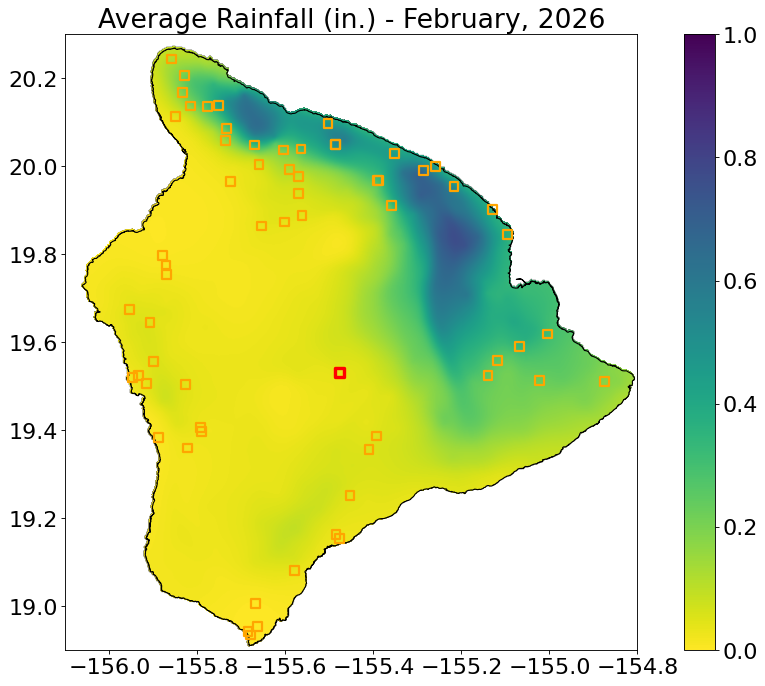

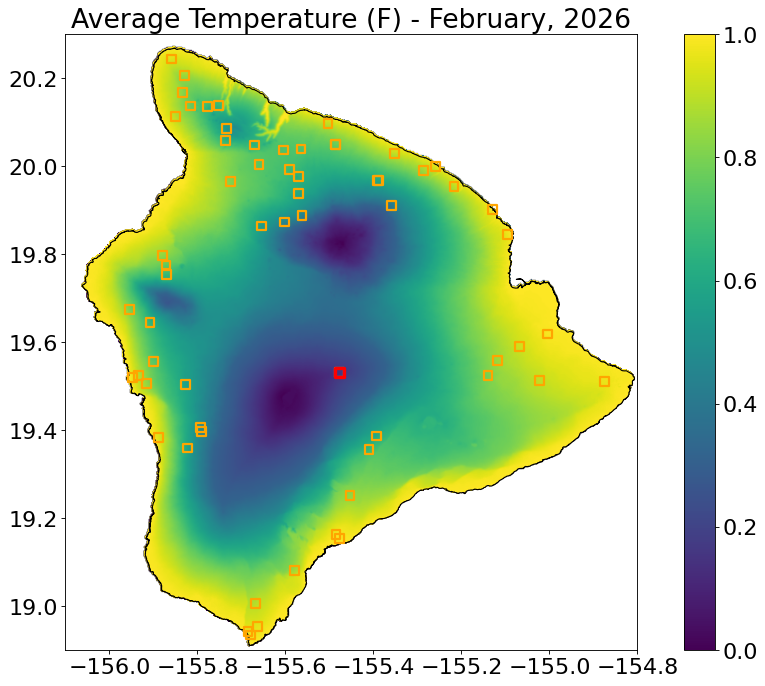

,id,FID,Polygon,Area,IS,musym,geometry
106,None,0,RID107,NaN,BI,660,"POLYGON ((-155.05747 19.59953, -155.05747 19.5..."
107,None,0,RID108,NaN,BI,956,"POLYGON ((-155.47609 20.05892, -155.47609 20.0..."
108,None,0,RID109,NaN,BI,202,"POLYGON ((-155.89768 19.6555, -155.89768 19.63..."
109,None,0,RID110,NaN,BI,HLMG,"POLYGON ((-158.16347 21.51691, -158.16347 21.4..."
110,None,0,RID111,NaN,BI,952,"POLYGON ((-155.2068 19.96392, -155.2068 19.943..."
111,None,0,RID112,NaN,MA,ISD,"POLYGON ((-156.38562 20.64516, -156.38562 20.6..."
112,None,0,RID113,NaN,MO,HvB3,"POLYGON ((-157.02678 21.13557, -157.02678 21.1..."
113,None,0,RID114,NaN,MO,HvB3,"POLYGON ((-157.02678 21.13557, -157.02678 21.1..."
114,None,0,RID115,NaN,BI,901,"POLYGON ((-155.11953 19.91162, -155.11953 19.8..."
115,None,0,RID116,NaN,BI,na,"POLYGON ((-155.4677 19.54052, -155.4677 19.520..."


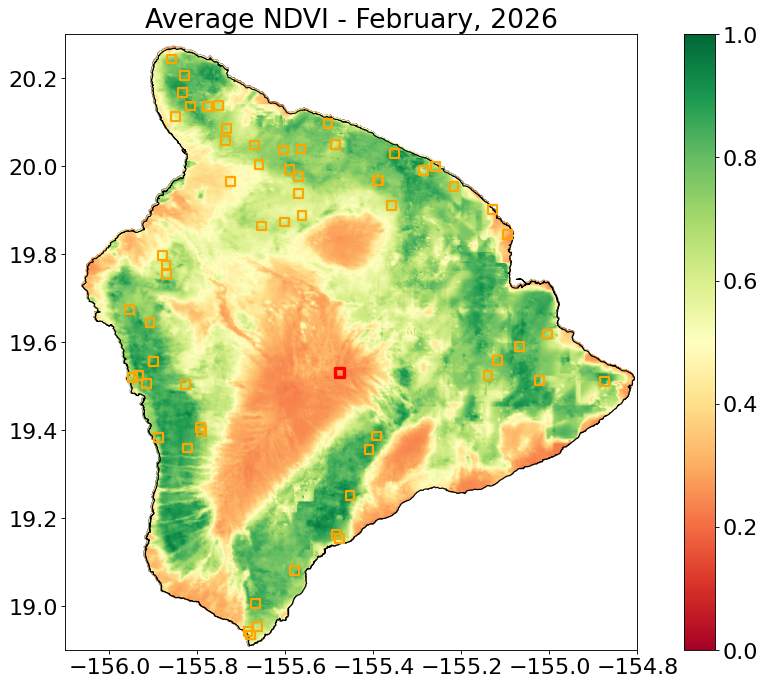

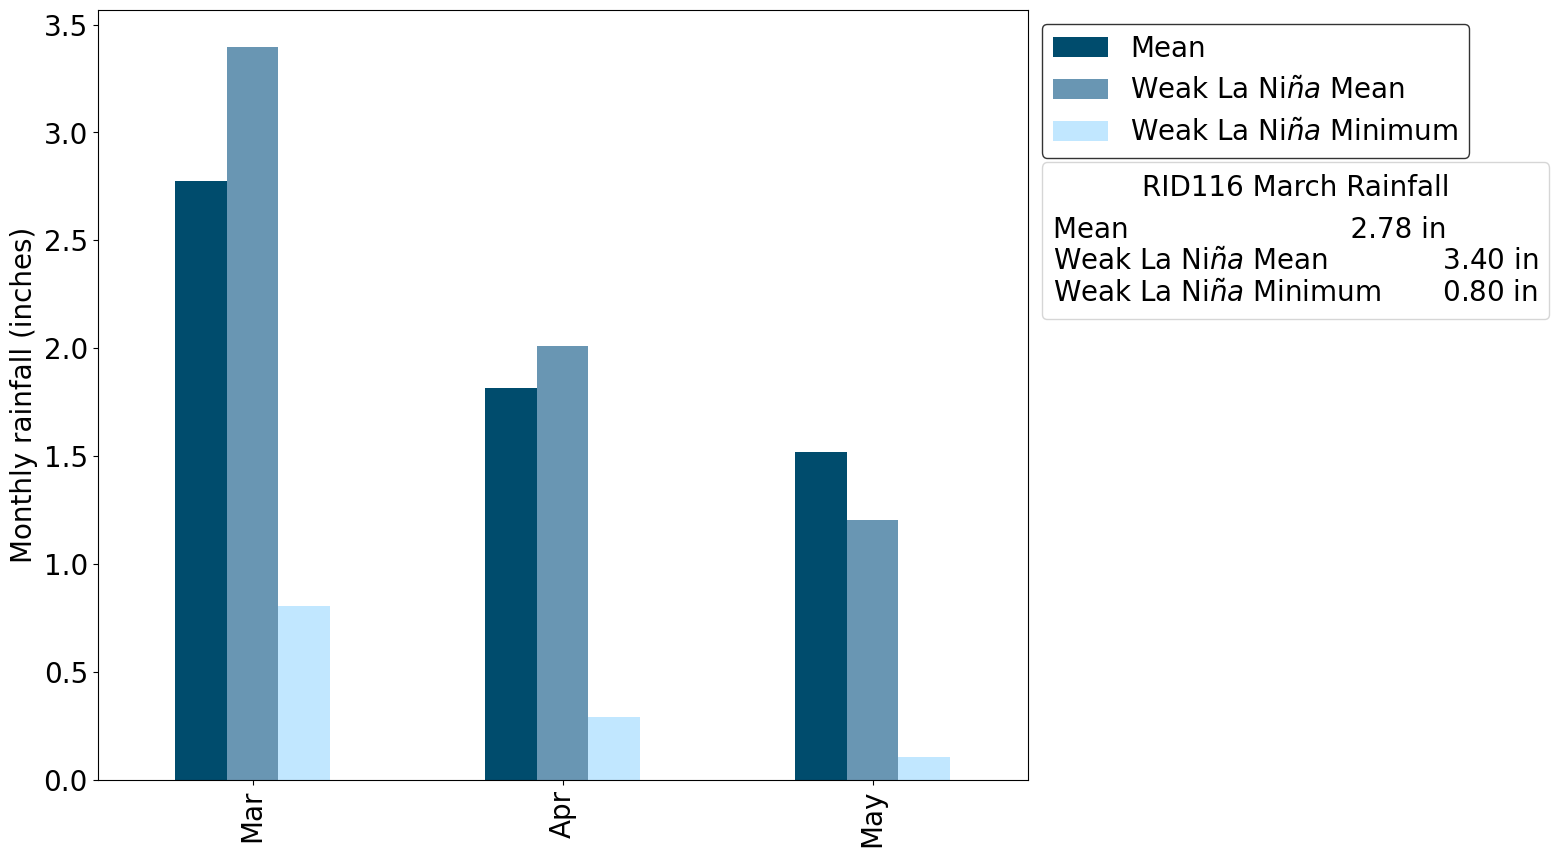

In [24]:
#Query Table
phases = 'SEL','WEL','NUT','WLA','SLA'

#Query Table
def phaseCalc(ANOM):
    if ANOM > 1.1: 
        phase='SEL'
    elif 1.1 >= ANOM >0.5:
        phase='WEL'
    elif 0.5>=ANOM>=-0.5:
        phase = 'NUT'
    elif -0.5> ANOM >= -1.1:
        phase = 'WLA'
    elif ANOM < -1.1:
        phase = 'SLA'
    else:
        print("Error")
    return phase

url = "https://www.cpc.ncep.noaa.gov/data/indices/Rnino34.ascii.txt"

ONI = pd.read_csv(
    url,
    sep=r"\s+",
    header=0,
    names=["YR", "MON", "ANOM"]
)
# ONI['PHASE'] = float(ONI['ANOM']).apply(phaseCalc)
ONI["ANOM"] = pd.to_numeric(ONI["ANOM"], errors="coerce")
ONI["PHASE"] = ONI["ANOM"].apply(phaseCalc)
ONI=ONI.sort_values(by=['MON', 'PHASE'])




rf = pd.read_csv(f'../RID/RID{r:03d}/RID{r:03d}_rf.csv')
rf = rf[rf['Year']>1949]
temp = pd.read_csv(f'../RID/RID{r:03d}/RID{r:03d}_tmean.csv')
query = pd.DataFrame()
m3=pd.DataFrame()
for i in months:
    for j in phases:
        #Get MRF, Me, Mn and anoms. Add to query ()
        MRF = (rf[(rf['Month']==i)]).RF_in.mean()
        MT = (temp[(temp['Month']==i)]).tmean_f.mean()
        phase = j
        count = len(ONI[(ONI['MON']==i)&(ONI['PHASE']==j)])
        list = ONI.loc[(ONI['MON'] == i) & (ONI['PHASE'] == j)].YR.values.tolist()
        dfrf = rf[rf['Year'].isin(list)]
        dft = temp[temp['Year'].isin(list)]
        MeRF = (dfrf[(dfrf['Month']==i)]).RF_in.mean()
        MnRF = (dfrf[(dfrf['Month']==i)]).RF_in.min()
        MeT = (dft[(dft['Month']==i)]).tmean_f.mean()
        MnT = (dft[(dft['Month']==i)]).tmean_f.min()
        MeAnom = MeRF - MRF
        MnAnom = MnRF - MRF
        #df2 = {}
        new_row = pd.DataFrame({'Month':i,'MRF': MRF, 'Phase':j,'Count':count,'MeRF':MeRF,'MnRF':MnRF,'MeAnom':MeAnom,'MnAnom':MnAnom,'MT':MT,'MeT':MeT,'MnT':MnT},index=[0])
        query=pd.concat([query, new_row],ignore_index=True)
        #query = query.append(df2,ignore_index=True)
        '''if i==11:
            MRF3M = query[query['Phase']==j].iloc[np.r_[0, -2:0]].MRF.sum()
            MeRF3M = query[query['Phase']==j].iloc[np.r_[0, -2:0]].MeRF.sum()
            MnRF3M = query[query['Phase']==j].iloc[np.r_[0, -2:0]].MnRF.sum()
        elif i==12:
            MRF3M = query[query['Phase']==j].iloc[np.r_[0:2, -1:0]].MRF.sum()
            MeRF3M = query[query['Phase']==j].iloc[np.r_[0:2, -1:0]].MeRF.sum()
        MnRF3M = query[query['Phase']==j].iloc[np.r_[0:2, -1:0]].MnRF.sum()
        else:
            MRF3M = query[query['Phase']==j][i-1:i+2].MRF.sum()
            MeRF3M = query[query['Phase']==j][i-1:i+2].MeRF.sum()
            MnRF3M = query[query['Phase']==j][i-1:i+2].MnRF.sum()
        m3=m3.append({'MRF3M':MRF3M,'MeRF3M':MeRF3M,'MnRF3M':MnRF3M},ignore_index=True)'''
        #Calculate quarterly forage production 


#query = pd.concat([query, m3], axis=1)


'''for k in np.arange(len(query)):
    MRF_90 = query['MRF3M'][k]
    MeRF_90 = query['MeRF3M'][k]
    MnRF_90 = query['MnRF3M'][k]
    qfpM = 643.1+234.1*MRF_90
    qfpMe = 643.1+234.1*MeRF_90
    qfpMn = 643.1+234.1*MnRF_90
    QFPMe_c = ((qfpMe-qfpM)/qfpM)*100
    QFPMn_c = ((qfpMn-qfpM)/qfpM)*100
    qfp = qfp.append({'QFPMe_c':QFPMe_c,'QFPMn_c':QFPMn_c},ignore_index=True)'''

#query=pd.concat([query, qfp], axis=1)
query.to_csv(f'../RID/RID{r:03d}/RID{r:03d}_query.csv')



island_lats = {'BI': {'xlim': [-156.1, -154.8], 'ylim': [18.9, 20.3]}, 'MA':{'xlim': [-156.72, -155.95], 'ylim': [20.55, 21.05]}, 
              'OA':{'xlim': [-158.3,-157.645], 'ylim': [21.25, 21.73]}, 'KA':{'xlim': [-159.8,-159.28], 'ylim': [21.86,22.25]}, 
              'KO':{'xlim': [-156.71,-156.52], 'ylim': [20.49, 20.61]}, 'LA':{'xlim': [-157.08,-156.8], 'ylim': [20.7, 20.95]}, 
              'MO':{'xlim': [-157.32,-156.7], 'ylim': [21.03, 21.23]}, } 



coastline = gpd.read_file('./shapefiles/Coastline.shp')
coastline = coastline.to_crs("epsg:4326")
ranches = gpd.read_file('./shapefiles/RID.shp')
ranches = ranches.to_crs("epsg:4326")
#rainfall = rasterio.open('rf_in.tif',nodata=noData)
#raster = rasterio.plot.show(rainfall, ax=ax,cmap='viridis_r')

with rasterio.open(f'./rain_monthly_maps/2020-/rainfall_{lastMonthYr}_{lastMonth:02d}.tif') as src:
    rf_mm = src.read(1, masked=True)

    rf_in = rf_mm/25.4

    with rasterio.open('output_raster.tif', 'w', **src.profile) as dst:
        dst.write(rf_in, 1)

a = rasterio.open('output_raster.tif')

y = ranches[ranches.Polygon == ranch_id]
fig, ax = plt.subplots(figsize=(15, 10), dpi=80)
coastline.plot(ax=ax, facecolor='none', edgecolor='black')
ranches.plot(ax=ax, facecolor='none',edgecolor='orange',linewidth=2)
y.plot(ax=ax, facecolor='none',edgecolor='red',linewidth=3)
rasterio.plot.show(a, ax=ax,cmap='viridis_r')
plt.rcParams['font.size'] = '20'
ax.set_ylim(island_lats[island]['ylim'])
ax.set_xlim(island_lats[island]['xlim'])
raster = rasterio.plot.show(a, ax=ax,cmap='viridis_r')
im=raster.get_images()[0]
cbar = fig.colorbar(im,ax=ax)
cbar.ax.tick_params(labelsize=20) 
monthName = calendar.month_name[int(lastMonth)]
plt.title(f'Average Rainfall (in.) - {monthName}, {lastMonthYr}')
plt.savefig(f'../RID/RID{r:03d}/RID{r:03d}_rf.png',bbox_inches="tight")
plt.show()

with rasterio.open(f'/Users/cherryleheu/Documents/HCDP/Data/monthly/tmean/tmean_{lastMonthYr}_{lastMonth:02d}.tif') as src:
    temp_c = src.read(1, masked=True)

    temp = (temp_c * 9/5) + 32
    noData = src.nodata
    with rasterio.open('output_raster.tif', 'w', **src.profile) as dst:
        dst.write(temp, 1)
        
temp_map = rasterio.open('output_raster.tif',noData=noData)

y = ranches[ranches.Polygon == ranch_id]
fig, ax = plt.subplots(figsize=(15, 10), dpi=80)
coastline.plot(ax=ax, facecolor='none', edgecolor='black')
ranches.plot(ax=ax, facecolor='none',edgecolor='orange',linewidth=2)
y.plot(ax=ax, facecolor='none',edgecolor='red',linewidth=3)
rasterio.plot.show(a, ax=ax,cmap='viridis')
plt.rcParams['font.size'] = '20'
ax.set_ylim(island_lats[island]['ylim'])
ax.set_xlim(island_lats[island]['xlim'])
raster = rasterio.plot.show(temp_map, ax=ax,cmap='viridis')
im=raster.get_images()[0]
cbar = fig.colorbar(im,ax=ax)
cbar.ax.tick_params(labelsize=20) 
monthName = calendar.month_name[int(lastMonth)]
plt.title(f'Average Temperature (F) - {monthName}, {lastMonthYr}')
plt.savefig(f'../RID/RID{r:03d}/RID{r:03d}_temp.png',bbox_inches="tight")
plt.show()

url = f'./NDVI_maps/NDVI_{int(lastMonthYr)}_{int(lastMonth):02d}.tif'
with rasterio.open(url) as src:
    ndvi = src.read(1, masked=True)
    noData = src.nodata
    with rasterio.open('output_raster_ndvi.tif', 'w', **src.profile) as dst:
        dst.write(ndvi, 1)
    
ndvi = rasterio.open('output_raster_ndvi.tif',noData=noData)
vmin = 0
vmax = 1
a = rasterio.open('output_raster.tif')

y = ranches[ranches.Polygon == ranch_id]
fig, ax = plt.subplots(figsize=(15, 10), dpi=80)
coastline.plot(ax=ax, facecolor='none', edgecolor='black')
ranches.plot(ax=ax, facecolor='none',edgecolor='orange',linewidth=2)
y.plot(ax=ax, facecolor='none',edgecolor='red',linewidth=3)
rasterio.plot.show(ndvi, ax=ax,vmin=vmin,vmax=vmax,cmap='RdYlGn')
plt.rcParams['font.size'] = '20'
ax.set_ylim(island_lats[island]['ylim'])
ax.set_xlim(island_lats[island]['xlim'])
raster = rasterio.plot.show(ndvi, ax=ax,cmap='RdYlGn')
im=raster.get_images()[0]
cbar = fig.colorbar(im,ax=ax)
cbar.ax.tick_params(labelsize=20) 
monthName = calendar.month_name[int(lastMonth)]
plt.title(f'Average NDVI - {monthName}, {int(lastMonthYr)}')
plt.savefig(f'../RID/RID{r:03d}/RID{r:03d}_ndvi.png',bbox_inches="tight")

def filter(rf_df,mode):
    if mode == 1:
        ENSO = []
        if ANOM > 1.1: 
            ENSO= rf_df[(rf_df['Month']>=a)&(rf_df['Month']<=b)].loc[rf_df['Phase'] == 'SEL']
            title="Strong El Nino"
        elif 1.1 >= ANOM >0.5:
            ENSO= rf_df[(rf_df['Month']>=a)&(rf_df['Month']<=b)].loc[rf_df['Phase'] == 'WEL']
            title="Weak El Nino"
        elif 0.5>=ANOM>=-0.5:
            ENSO= rf_df[(rf_df['Month']>=a)&(rf_df['Month']<=b)].loc[rf_df['Phase'] == 'NUT']
            title="Neutral"
            print(ENSO)
        elif -0.5> ANOM >= -1.1:
            ENSO= rf_df[(rf_df['Month']>=a)&(rf_df['Month']<=b)].loc[rf_df['Phase'] == 'WLA']
            title=r'Weak La Ni$\tilde{n}a$'
        elif ANOM < -1.1:
            ENSO= rf_df[(rf_df['Month']>=a)&(rf_df['Month']<=b)].loc[rf_df['Phase'] == 'SLA']
            title=r'Strong La Ni$\tilde{n}a$'
        else:
            print("Error")
        return ENSO, title
    if mode == 2:
        ENSO = []
        if ANOM > 1.1: 
            ENSO= rf_df[(rf_df['Month']>=a)|(rf_df['Month']<=b)].loc[rf_df['Phase'] == 'SEL']
            title="Strong El Nino"
        elif 1.1 >= ANOM >0.5:
            ENSO= rf_df[(rf_df['Month']>=a)|(rf_df['Month']<=b)].loc[rf_df['Phase'] == 'WEL']
            title="Weak El Nino"
        elif 0.5>=ANOM>=-0.5:
            ENSO= rf_df[(rf_df['Month']>=a)|(rf_df['Month']<=b)].loc[rf_df['Phase'] == 'NUT']
            title="Neutral"
        elif -0.5> ANOM >= -1.1:
            ENSO= rf_df[(rf_df['Month']>=a)|(rf_df['Month']<=b)].loc[rf_df['Phase'] == 'WLA']
            title=r'Weak La Ni$\tilde{n}a$'
        elif ANOM < -1.1:
            ENSO= rf_df[(rf_df['Month']>=a)|(rf_df['Month']<=b)].loc[rf_df['Phase'] == 'SLA']
            title=r'Strong La Ni$\tilde{n}a$'
        else:
            print("Error")
        return ENSO, title


ANOM = ONI.iloc[-1]['ANOM']

now = datetime.now()

thisMonthName = (now).strftime("%B")
now = datetime.now()
month = now.strftime("%b")

a = int((now+relativedelta(months=+0)).strftime("%m"))
b = int((now+relativedelta(months=+2)).strftime("%m"))

table=pd.read_csv(f"../RID/RID{r:03d}/RID{r:03d}_query.csv",index_col=0)
rf_df=pd.DataFrame({'A' : []})


if a == 11 or a == 12:
    #creates a table that is from March to Feb
    rf_df=pd.concat([table, table.loc[:9]],ignore_index=True)
    N=10
    rf_df=rf_df.iloc[N:,:]
    mode = 2
else:
    rf_df=table
    mode = 1

ENSO = filter(rf_df,mode)[0]
title=filter(rf_df,mode)[1]
ENSO['MonthName']= ENSO['Month'].astype(np.uint8).apply(lambda x: calendar.month_abbr[x])

#all mean
mean=ENSO['MRF'].iloc[0]
#phase mean
p_mean = ENSO['MeRF'].iloc[0]
#phase min
p_min = ENSO['MnRF'].iloc[0]


fig, ax = plt.subplots(figsize=(12,10))
line1 = ENSO.plot(ax=ax,x='MonthName',y=['MRF','MeRF','MnRF'],kind="bar",legend=False,color=['#004c6d','#6996b3','#c1e7ff'])

ax.set_ylabel("Monthly rainfall (inches)",fontsize=20)
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
first_legend = ax.legend(['Mean', '%s Mean' % title, '%s Minimum'% title],fontsize=20,bbox_to_anchor=(1,1),edgecolor="black", loc='upper left')


second_legend = ax.legend([f"Mean                         {mean:.2f} in\n{title} Mean             {p_mean:.2f} in\n{title} Minimum       {p_min:.2f} in"], loc='center left', 
                        handlelength=0, handletextpad=0,bbox_to_anchor=(1, 0.7), title=f'RID{r:03d} {thisMonthName} Rainfall',fontsize=20)
second_legend.get_title().set_fontsize('20') 
ax.add_artist(first_legend)

#ax.add_artist(second_legend)
ax.set(xlabel=None)
plt.savefig(f"../RID/RID{r:03d}/RID{r:03d}_rainfall.png",bbox_inches="tight")



#Read soils shapefile, filter data
soils_path = './shapefiles/soils/soils.shp'
soils_shp = gpd.read_file(soils_path)
soils = soils_shp[['areasymbol','musym','geometry']]

pasture = pd.read_csv('./528/SoilPasture.csv')
soils_0 = pasture.loc[pasture['Pasture Group'] == 0]

nullSymbols = pasture[pasture['Poor'].isna()]['SoilSymbol'].tolist()
nullSymbols.extend(soils_0['SoilSymbol'].tolist())



ranches = gpd.read_file('./shapefiles/RID.shp')
ranches = ranches.to_crs("epsg:4326")

y = ranches[ranches.Polygon == ranch_id]
a=y['Polygon']
clip = gpd.clip(soils,ranches.loc[y.index,'geometry'])
clip_proj = clip.to_crs(epsg=3857)
clip_proj['area']=clip_proj.geometry.area
final = clip_proj.dissolve(by='musym',aggfunc='sum').reset_index()
df = final.sort_values(by='area', ascending=False)
index_position = 0
musym = df['musym'].iloc[index_position]
if musym in nullSymbols:
    while musym in nullSymbols and index_position < len(df) - 1:
        index_position += 1
        musym = df['musym'].iloc[index_position]
        
    if musym in nullSymbols:
        musym = 'na'
    else:
        print(f'Musym changed to: {musym}')

ranches.loc[y.index, 'musym']=musym
ranches.to_file('./shapefiles/RID.shp')  
musym

ranches = gpd.read_file('./shapefiles/RID.shp')
ranches = ranches.to_crs("epsg:4326")
ranches.tail(10)

In [43]:
# #NDVI
# ranchshp = gpd.read_file('./shapefiles/RID.shp')
# ranch = ranchshp.loc[ranchshp['Polygon']==f"RID{r:03d}"]
# ndvi = pd.DataFrame({'Year': [],'Month':[],'NDVI': []})
# for i in np.arange(2000,int(thisYear)+1):
#     if i == 2000:
#         range = np.arange(2,13)
#     else:
#         range=np.arange(1,13)
#     for j in range:
#         if int(i) == int(thisYear) and int(j)==(thisMonth):
#             break
#         with rasterio.open(f'./NDVImaps/{i}_{j:02d}_NDVI.tif') as src:
#             affine = src.transform
#             array = src.read(1)
#             nodata = src.nodata
#             df_zonal_stats = pd.DataFrame(zonal_stats(ranch, array, affine=affine,nodata=nodata,stats = ['mean']))
#         NDVI= df_zonal_stats['mean'].iloc[0]
#         new_row = pd.DataFrame({'Year':i,'Month':j,'NDVI':NDVI},index=[0])
#         ndvi=pd.concat([ndvi, new_row],ignore_index=True)
#         #ndvi=ndvi.append({'Year':i,'Month':j,'NDVI':NDVI},ignore_index=True)
# ndvi['NDVI'].replace(0, np.nan, inplace=True)
# ndvi['datetime']=pd.date_range('2/1/2000',lastM,freq='MS')
# ndvi.to_csv(f'../RID/RID{r:03d}/RID{r:03d}_ndvi.csv')


# #average monthly
# def ndvi_avg(arr):
#     arr = arr.drop(['datetime'], axis=1)
#     ndvidf = arr.groupby(['Month'],as_index=False).mean()
#     ndvidf['Month'] = ndvidf['Month'].astype(np.uint8).apply(lambda x: calendar.month_name[x])
#     ndvidf['rolledMonth'] = np.roll(ndvidf.Month, -a)
#     ndvidf['rolledNDVI'] = np.roll(ndvidf.NDVI, -a)
#     ndvidf = ndvidf.rename(columns={"NDVI": "oldNDVI", "rolledNDVI": "NDVI","Month":"oldMonth","rolledMonth":"Month"})
#     return ndvidf

# #last 12 months
# def ndvi_12m(arr):
#     ndvi12m = arr.copy()
#     ndvi12m['Month'] = ndvi12m['Month'].astype(np.uint8).apply(lambda x: calendar.month_name[x]) 
#     ndvi12m = ndvi12m.tail(12)
#     return ndvi12m


# ndvi = pd.read_csv(f'../RID/RID{r:03d}/RID{r:03d}_ndvi.csv',index_col=0)
# a = int(ndvi['Month'].iloc[-1])
# ndvidf=ndvi_avg(ndvi)
# ndvi12m=ndvi_12m(ndvi)
# ndvidf=ndvidf.drop(['Year'],axis=1)
# ndvi12m=ndvi12m.drop(['Year','datetime'],axis=1)
# ndvidf.to_csv(f'../RID/RID{r:03d}/RID{r:03d}_ndvi_month.csv') 
# ndvi12m.to_csv(f'../RID/RID{r:03d}/RID{r:03d}_ndvi_12m.csv')

In [ ]:


# y = ranches[ranches.Polygon == ranch_id]
# fig, ax = plt.subplots(figsize=(15, 10), dpi=80)
# coastline.plot(ax=ax, facecolor='none', edgecolor='black')
# ranches.plot(ax=ax, facecolor='none',edgecolor='orange',linewidth=2)
# y.plot(ax=ax, facecolor='none',edgecolor='red',linewidth=3)
# rasterio.plot.show(et, ax=ax,cmap='viridis')
# plt.rcParams['font.size'] = '20'
# ax.set_ylim(island_lats[island]['ylim'])
# ax.set_xlim(island_lats[island]['xlim'])
# raster = rasterio.plot.show(et, ax=ax,cmap='viridis_r')
# im=raster.get_images()[0]
# cbar = fig.colorbar(im,ax=ax)
# cbar.ax.tick_params(labelsize=20) 
# monthName = calendar.month_name[int(lastMonth)]
# plt.title(f'Average Evapotranspiration (mm/day) - {monthName}, {int(lastMonthYr)}')
# plt.savefig(f'../RID/RID{r:03d}/RID{r:03d}_et.png',bbox_inches="tight")
# plt.show()




# #lastMonth = 9
# url = f'./NDVIMaps/{int(lastMonthYr)}_{lastMonth}_ndvi.tif'
# with rasterio.open(url) as src:
#    ndvi = src.read(1, masked=True)
# ndvi = rasterio.open(url,nodata=noData)




# y = ranches[ranches.Polygon == ranch_id]
# fig, ax = plt.subplots(figsize=(15, 10), dpi=80)
# coastline.plot(ax=ax, facecolor='none', edgecolor='black')
# ranches.plot(ax=ax, facecolor='none',edgecolor='orange',linewidth=2)
# y.plot(ax=ax, facecolor='none',edgecolor='blue',linewidth=2)
# rasterio.plot.show(ndvi, ax=ax,cmap='RdYlGn')
# plt.rcParams['font.size'] = '20'
# ax.set_ylim(island_lats[island]['ylim'])
# ax.set_xlim(island_lats[island]['xlim'])
# raster = rasterio.plot.show(ndvi, ax=ax,cmap='RdYlGn')
# im=raster.get_images()[0]
# cbar = fig.colorbar(im,ax=ax)
# cbar.ax.tick_params(labelsize=20) 
# monthName = calendar.month_name[int(lastMonth)]
# plt.title(f'Average NDVI - {monthName}, {int(lastMonthYr)}')
# plt.savefig(f'../RID/RID{r:03d}/RID{r:03d}_ndvi.png',bbox_inches="tight")
# plt.show()

In [ ]:
# #ET

# ranchshp = gpd.read_file('./shapefiles/RID.shp')
# ranch = ranchshp.loc[ranchshp['Polygon']==f"RID{r:03d}"]
# et = pd.DataFrame({'Year': [],'Month':[],'ET': []})
# for i in np.arange(2001,int(thisYear)+1):
#     for j in np.arange(1,13):
#         if int(i) == int(thisYear) and int(j)==(thisMonth):
#             break
#         else:
#             with rasterio.open(f'./ETmaps/{i}_{j:02d}_et.tif') as src:
#                 affine = src.transform
#                 array = src.read(1)
#                 nodata = src.nodata
#                 df_zonal_stats = pd.DataFrame(zonal_stats(ranch, array, affine=affine,nodata=nodata,stats = ['mean']))
#             ET= df_zonal_stats['mean'].iloc[0]
#             new_row = pd.DataFrame({'Year':i,'Month':j,'ET':ET},index=[0])
#             et=pd.concat([et, new_row],ignore_index=True)
#             #et=et.append({'Year':i,'Month':j,'ET':ET},ignore_index=True)

# et['ET'].replace(0, np.nan, inplace=True)
# et['datetime']=pd.date_range('1/1/2001',lastM,freq='MS')
# et['ET']=et['ET']/8
# et.to_csv(f'../RID/RID{r:03d}/RID{r:03d}_et.csv')

# #average monthly
# def et_avg(arr):
#     arr = arr.drop(['datetime'], axis=1)
#     etdf = arr.groupby(['Month'],as_index=False).mean()
#     etdf['Month'] = etdf['Month'].astype(np.uint8).apply(lambda x: calendar.month_name[x])
#     etdf['rolledMonth'] = np.roll(etdf.Month, -a)
#     etdf['rolledET'] = np.roll(etdf.ET, -a)
#     etdf = etdf.rename(columns={"ET": "oldET", "rolledET": "ET","Month":"oldMonth","rolledMonth":"Month"})
#     return etdf

# #last 12 months
# def et_12m(arr):
#     et12m = arr.copy()
#     et12m['Month'] = et12m['Month'].astype(np.uint8).apply(lambda x: calendar.month_name[x]) 
#     et12m = et12m.tail(12)
#     return et12m


# et = pd.read_csv(f'../RID/RID{r:03d}/RID{r:03d}_et.csv',index_col=0)
# a = int(et['Month'].iloc[-1])
# etdf=et_avg(et)
# etdf=etdf.drop(['Year'],axis=1)
# et12m=et_12m(et)
# et12m=et12m.drop(['Year','datetime'],axis=1)
# etdf.to_csv(f'../RID/RID{r:03d}/RID{r:03d}_et_month.csv') 
# et12m.to_csv(f'../RID/RID{r:03d}/RID{r:03d}_et_12m.csv')
